# Data Quality Assessment (DQA)

This notebooks focuses on the training data and especially on data inbalance.

- DR Flags by Hour
- Power Consumption by Hour
- Augmentation

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("../data/regression/regression-train.csv")

In [8]:
df.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [9]:
# Convert timestamp to datetime
df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local'])

In [10]:
# Basic temporal features
df['hour'] = df['Timestamp_Local'].dt.hour
df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df['Timestamp_Local'].dt.month  # Capture seasonality
df['day_of_year'] = df['Timestamp_Local'].dt.dayofyear

In [11]:
df[(df['Timestamp_Local'] >= '2019-02-12 00:00:00') & (df['Timestamp_Local'] < '2019-02-13 00:00:00')]

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW,hour,day_of_week,is_weekend,month,day_of_year
4032,siteA,2019-02-12 00:00:00,21.90,0.0,0.4,0,0.0,0,1,0,2,43
4033,siteA,2019-02-12 00:15:00,21.77,0.0,0.4,0,0.0,0,1,0,2,43
4034,siteA,2019-02-12 00:30:00,21.65,0.0,0.4,0,0.0,0,1,0,2,43
4035,siteA,2019-02-12 00:45:00,21.52,0.0,0.4,0,0.0,0,1,0,2,43
4036,siteA,2019-02-12 01:00:00,21.40,0.0,0.4,0,0.0,1,1,0,2,43
...,...,...,...,...,...,...,...,...,...,...,...,...
39163,siteB,2019-02-12 22:45:00,14.07,0.0,0.4,0,0.0,22,1,0,2,43
39164,siteB,2019-02-12 23:00:00,13.90,0.0,0.4,0,0.0,23,1,0,2,43
39165,siteB,2019-02-12 23:15:00,13.92,0.0,0.4,0,0.0,23,1,0,2,43
39166,siteB,2019-02-12 23:30:00,13.95,0.0,0.4,0,0.0,23,1,0,2,43


In [12]:
# Example 1: DR Flag = 1
# sample_df = df[(df['Timestamp_Local'] >= '2019-01-09 00:00:00') & (df['Timestamp_Local'] < '2019-01-12 00:00:00')]


sample_df = df[(df['Timestamp_Local'] >= '2019-01-17 00:00:00') & (df['Timestamp_Local'] < '2019-01-20 00:00:00')]

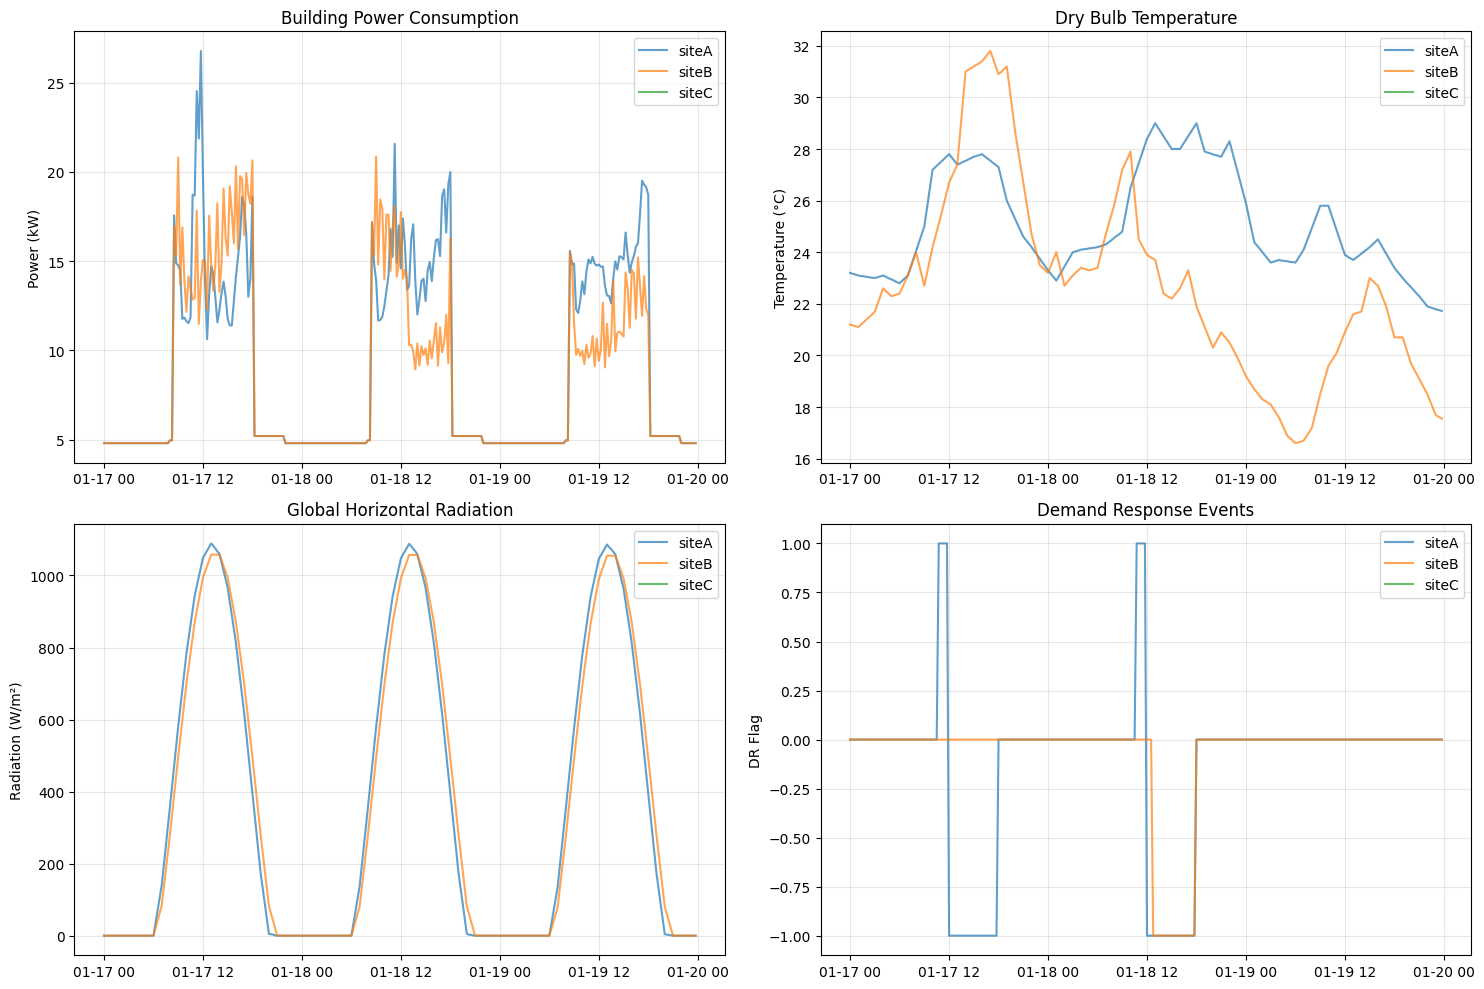

In [13]:
# Plot time series for each variable
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for site in df['Site'].unique():
    site_data = sample_df[sample_df['Site'] == site].sort_values('Timestamp_Local')
    
    axes[0,0].plot(site_data['Timestamp_Local'], site_data['Building_Power_kW'], 
                   label=site, alpha=0.7)
    axes[0,1].plot(site_data['Timestamp_Local'], site_data['Dry_Bulb_Temperature_C'], 
                   label=site, alpha=0.7)
    axes[1,0].plot(site_data['Timestamp_Local'], site_data['Global_Horizontal_Radiation_W/m2'], 
                   label=site, alpha=0.7)
    axes[1,1].plot(site_data['Timestamp_Local'], site_data['Demand_Response_Flag'], 
                   label=site, alpha=0.7)

# DR events - NOW FILTERED TO FIRST 24 HOURS
# dr_events_sample = sample_df[sample_df['Demand_Response_Flag'] != 0]  # Filter from sample_df instead of full df
# for site in df['Site'].unique():
#     site_dr = dr_events_sample[dr_events_sample['Site'] == site]
#     axes[1,1].scatter(site_dr['Timestamp_Local'], site_dr['Demand_Response_Flag'], 
#                      label=f'{site}', alpha=0.6, s=10)

axes[0,0].set_title('Building Power Consumption')
axes[0,0].set_ylabel('Power (kW)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].set_title('Dry Bulb Temperature')
axes[0,1].set_ylabel('Temperature (°C)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].set_title('Global Horizontal Radiation')
axes[1,0].set_ylabel('Radiation (W/m²)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].set_title('Demand Response Events')
axes[1,1].set_ylabel('DR Flag')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# DR Flag data imbalance

Demand Response Flag Distribution:
Demand_Response_Flag
-1      2262
 0    102011
 1       847
Name: count, dtype: int64

Percentages:
Demand_Response_Flag
-1     2.151826
 0    97.042428
 1     0.805746
Name: proportion, dtype: float64


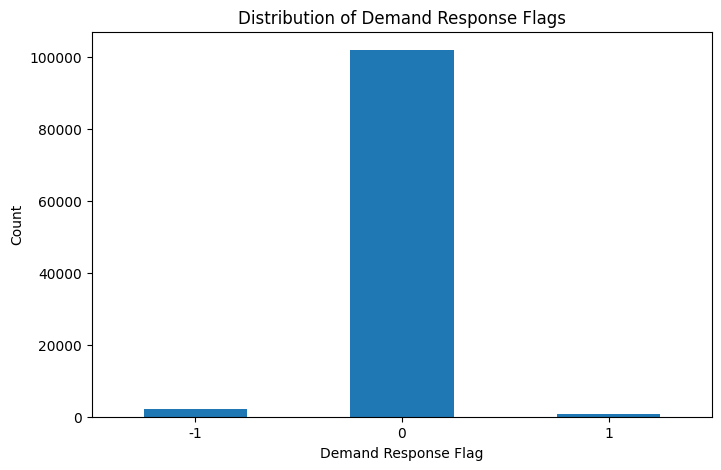

In [14]:
print("Demand Response Flag Distribution:")
print(df['Demand_Response_Flag'].value_counts().sort_index())
print("\nPercentages:")
print(df['Demand_Response_Flag'].value_counts(normalize=True).sort_index() * 100)

# Visualize
plt.figure(figsize=(8, 5))
df['Demand_Response_Flag'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Demand Response Flags')
plt.xlabel('Demand Response Flag')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## DR Flags at Night

In [15]:
# First, extract the hour from the Timestamp_Local column
df['hour'] = df['Timestamp_Local'].dt.hour

# Then group by hour and count the Demand_Response_Flag values
dr_counts_by_hour = df.groupby(['hour', 'Demand_Response_Flag']).size().unstack(fill_value=0)

print(dr_counts_by_hour)

Demand_Response_Flag   -1     0    1
hour                                
0                       0  4380    0
1                       0  4380    0
2                       0  4380    0
3                       0  4380    0
4                       0  4380    0
5                       0  4380    0
6                       0  4380    0
7                       0  4380    0
8                       0  4380    0
9                       0  4380    0
10                      0  4269  111
11                     38  4085  257
12                    344  3977   59
13                    376  3920   84
14                    376  3920   84
15                    376  3920   84
16                    376  3920   84
17                    376  3920   84
18                      0  4380    0
19                      0  4380    0
20                      0  4380    0
21                      0  4380    0
22                      0  4380    0
23                      0  4380    0


In [16]:
# Alternative: Show as a regular grouped dataframe
dr_counts = df.groupby(['hour', 'Demand_Response_Flag']).size().reset_index(name='count')
print(dr_counts)

    hour  Demand_Response_Flag  count
0      0                     0   4380
1      1                     0   4380
2      2                     0   4380
3      3                     0   4380
4      4                     0   4380
5      5                     0   4380
6      6                     0   4380
7      7                     0   4380
8      8                     0   4380
9      9                     0   4380
10    10                     0   4269
11    10                     1    111
12    11                    -1     38
13    11                     0   4085
14    11                     1    257
15    12                    -1    344
16    12                     0   3977
17    12                     1     59
18    13                    -1    376
19    13                     0   3920
20    13                     1     84
21    14                    -1    376
22    14                     0   3920
23    14                     1     84
24    15                    -1    376
25    15    

In [17]:
# Group by Site and hour
dr_counts_by_site_hour = df.groupby(['Site', 'hour', 'Demand_Response_Flag']).size().unstack(fill_value=0)
print(dr_counts_by_site_hour)

Demand_Response_Flag  -1     0   1
Site  hour                        
siteA 0                0  1460   0
      1                0  1460   0
      2                0  1460   0
      3                0  1460   0
      4                0  1460   0
...                   ..   ...  ..
siteC 19               0  1460   0
      20               0  1460   0
      21               0  1460   0
      22               0  1460   0
      23               0  1460   0

[72 rows x 3 columns]


## DR Flags x Power Consumption kW

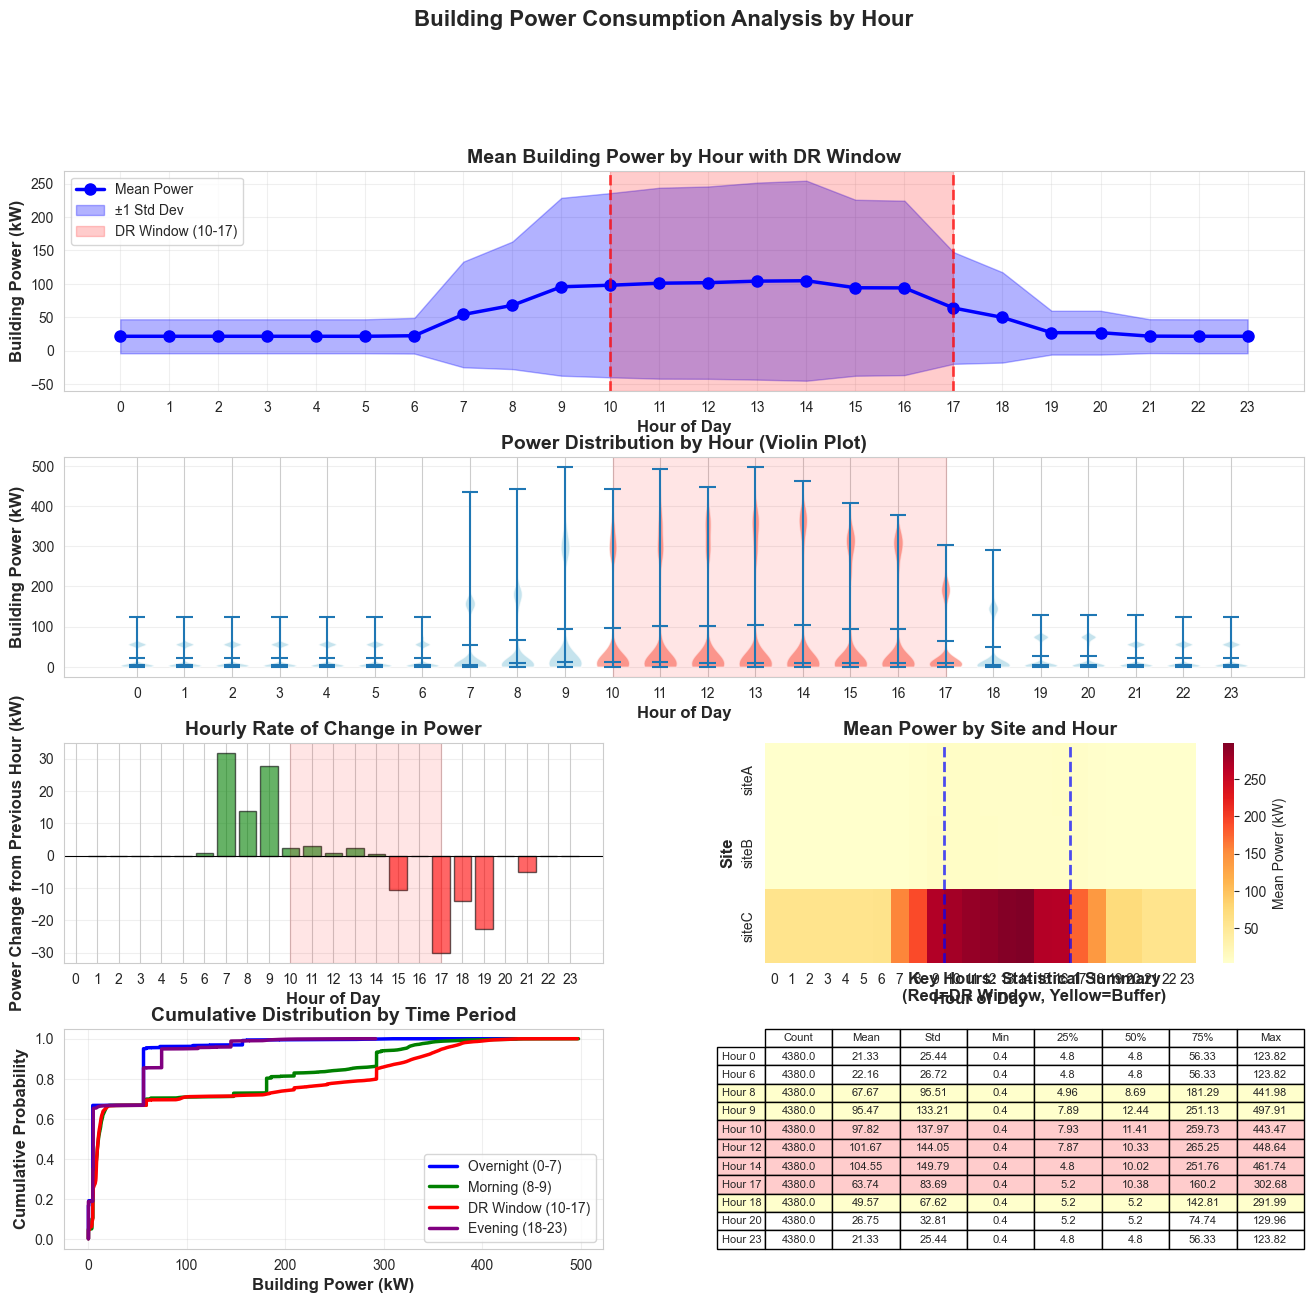

DETAILED HOURLY POWER STATISTICS
      Count    Mean     Std  Min   25%    50%     75%     Max
hour                                                         
0      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
1      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
2      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
3      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
4      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
5      4380   21.33   25.44  0.4  4.80   4.80   56.33  123.82
6      4380   22.16   26.72  0.4  4.80   4.80   56.33  123.82
7      4380   53.99   79.12  0.4  4.80   4.80  156.74  435.17
8      4380   67.67   95.51  0.4  4.96   8.69  181.29  441.98
9      4380   95.47  133.21  0.4  7.89  12.44  251.13  497.91
10     4380   97.82  137.97  0.4  7.93  11.41  259.73  443.47
11     4380  100.82  142.99  0.4  7.99  10.99  268.60  492.79
12     4380  101.67  144.05  0.4  7.87  10.33  265.25  448.64
13     4380  103.93  147.55  0.4  5.6

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a comprehensive analysis
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# ===== PLOT 1: Mean Power by Hour with Std Bands =====
ax1 = fig.add_subplot(gs[0, :])
power_by_hour = df.groupby('hour')['Building_Power_kW'].agg(['mean', 'std', 'min', 'max'])

ax1.plot(power_by_hour.index, power_by_hour['mean'], 
         marker='o', linewidth=2.5, markersize=8, label='Mean Power', color='blue')
ax1.fill_between(power_by_hour.index, 
                  power_by_hour['mean'] - power_by_hour['std'],
                  power_by_hour['mean'] + power_by_hour['std'],
                  alpha=0.3, color='blue', label='±1 Std Dev')

# Add DR window
ax1.axvspan(10, 17, alpha=0.2, color='red', label='DR Window (10-17)')
ax1.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.axvline(x=17, color='red', linestyle='--', linewidth=2, alpha=0.7)

ax1.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax1.set_ylabel('Building Power (kW)', fontsize=12, fontweight='bold')
ax1.set_title('Mean Building Power by Hour with DR Window', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24))

# ===== PLOT 2: Power Distribution by Hour (Violin Plot) =====
ax2 = fig.add_subplot(gs[1, :])
# Sample data for violin plot (full data might be too large)
sample_size = min(1000, len(df) // 24)
df_sample = df.groupby('hour').apply(lambda x: x.sample(min(sample_size, len(x)))).reset_index(drop=True)

parts = ax2.violinplot([df[df['hour']==h]['Building_Power_kW'].values for h in range(24)],
                        positions=range(24), widths=0.7, showmeans=True, showmedians=True)

# Color the DR window differently
for i, pc in enumerate(parts['bodies']):
    if 10 <= i <= 17:
        pc.set_facecolor('salmon')
        pc.set_alpha(0.7)
    else:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)

ax2.axvspan(10, 17, alpha=0.1, color='red')
ax2.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax2.set_ylabel('Building Power (kW)', fontsize=12, fontweight='bold')
ax2.set_title('Power Distribution by Hour (Violin Plot)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(0, 24))
ax2.grid(True, alpha=0.3, axis='y')

# ===== PLOT 3: Hourly Power Change (Rate of Change) =====
ax3 = fig.add_subplot(gs[2, 0])
power_change = power_by_hour['mean'].diff()

colors = ['green' if x > 0 else 'red' for x in power_change]
ax3.bar(power_change.index, power_change.values, color=colors, alpha=0.6, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axvspan(10, 17, alpha=0.1, color='red')

ax3.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax3.set_ylabel('Power Change from Previous Hour (kW)', fontsize=12, fontweight='bold')
ax3.set_title('Hourly Rate of Change in Power', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(range(0, 24))

# ===== PLOT 4: Power by Site and Hour (Heatmap) =====
ax4 = fig.add_subplot(gs[2, 1])
power_by_site_hour = df.groupby(['Site', 'hour'])['Building_Power_kW'].mean().unstack()

sns.heatmap(power_by_site_hour, annot=False, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Power (kW)'}, ax=ax4)
ax4.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax4.set_ylabel('Site', fontsize=12, fontweight='bold')
ax4.set_title('Mean Power by Site and Hour', fontsize=14, fontweight='bold')

# Add vertical lines for DR window
for x in [10, 17]:
    ax4.axvline(x=x, color='blue', linestyle='--', linewidth=2, alpha=0.7)

# ===== PLOT 5: Cumulative Distribution of Power by Hour Groups =====
ax5 = fig.add_subplot(gs[3, 0])

# Define hour groups
overnight = df[df['hour'].isin(range(0, 8))]['Building_Power_kW']
morning = df[df['hour'].isin(range(8, 10))]['Building_Power_kW']
dr_window = df[df['hour'].isin(range(10, 18))]['Building_Power_kW']
evening = df[df['hour'].isin(range(18, 24))]['Building_Power_kW']

for data, label, color in [
    (overnight, 'Overnight (0-7)', 'blue'),
    (morning, 'Morning (8-9)', 'green'),
    (dr_window, 'DR Window (10-17)', 'red'),
    (evening, 'Evening (18-23)', 'purple')
]:
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax5.plot(sorted_data, cumulative, label=label, linewidth=2.5, color=color)

ax5.set_xlabel('Building Power (kW)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax5.set_title('Cumulative Distribution by Time Period', fontsize=14, fontweight='bold')
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True, alpha=0.3)

# ===== PLOT 6: Statistical Summary Table =====
ax6 = fig.add_subplot(gs[3, 1])
ax6.axis('tight')
ax6.axis('off')

# Create summary statistics
summary_stats = df.groupby('hour')['Building_Power_kW'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('25%', lambda x: x.quantile(0.25)),
    ('50%', lambda x: x.quantile(0.50)),
    ('75%', lambda x: x.quantile(0.75)),
    ('Max', 'max')
]).round(2)

# Show only key hours
key_hours = [0, 6, 8, 9, 10, 12, 14, 17, 18, 20, 23]
summary_display = summary_stats.loc[key_hours]

table = ax6.table(cellText=summary_display.values,
                  rowLabels=[f'Hour {h}' for h in key_hours],
                  colLabels=summary_display.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

# Color code the rows - FIXED indexing
for i, hour in enumerate(key_hours):
    if 10 <= hour <= 17:
        # Color row (header is row 0, data starts at row 1)
        for j in range(-1, len(summary_display.columns)):  # -1 includes row label
            try:
                table[(i+1, j)].set_facecolor('#ffcccc')
            except KeyError:
                pass
    elif 8 <= hour <= 9 or 18 <= hour <= 19:
        for j in range(-1, len(summary_display.columns)):
            try:
                table[(i+1, j)].set_facecolor('#ffffcc')
            except KeyError:
                pass

ax6.set_title('Key Hours: Statistical Summary\n(Red=DR Window, Yellow=Buffer)', 
              fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Building Power Consumption Analysis by Hour', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('power_analysis_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== PRINT DETAILED STATISTICS =====
print("="*80)
print("DETAILED HOURLY POWER STATISTICS")
print("="*80)
print(summary_stats)

print("\n" + "="*80)
print("HOURLY POWER CHANGE (Rate of Change)")
print("="*80)
print(power_change.round(3))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Find minimum and maximum
min_hour = power_by_hour['mean'].idxmin()
max_hour = power_by_hour['mean'].idxmax()
print(f"Minimum mean power: Hour {min_hour} ({power_by_hour['mean'][min_hour]:.2f} kW)")
print(f"Maximum mean power: Hour {max_hour} ({power_by_hour['mean'][max_hour]:.2f} kW)")

# Find ramp-up period
threshold = power_by_hour['mean'].max() * 0.1  # 10% of max as significant change
significant_increases = power_change[power_change > threshold]
if len(significant_increases) > 0:
    ramp_up_start = significant_increases.index.min()
    print(f"\nMorning ramp-up begins: Hour {ramp_up_start}")
    print(f"Power increase: {power_change[ramp_up_start]:.2f} kW")

# Find ramp-down period
significant_decreases = power_change[power_change < -threshold]
if len(significant_decreases) > 0:
    ramp_down_start = significant_decreases.index.min()
    print(f"\nEvening ramp-down begins: Hour {ramp_down_start}")
    print(f"Power decrease: {power_change[ramp_down_start]:.2f} kW")

# Operational hours (where power is significantly above minimum)
mean_min_power = power_by_hour['mean'].min()
operational_threshold = mean_min_power + (power_by_hour['mean'].max() - mean_min_power) * 0.25
operational_hours = power_by_hour[power_by_hour['mean'] > operational_threshold].index.tolist()
print(f"\nOperational hours (>25% of range above minimum): {operational_hours}")

# Compare to DR window
print(f"\nDR Window: Hours 10-17")
print(f"Recommended range based on power patterns: {operational_hours}")

# Calculate statistics for different periods
print("\n" + "="*80)
print("POWER STATISTICS BY PERIOD")
print("="*80)

periods = {
    'Overnight (0-7)': range(0, 8),
    'Morning Buffer (8-9)': range(8, 10),
    'DR Window (10-17)': range(10, 18),
    'Evening Buffer (18-19)': range(18, 20),
    'Night (20-23)': range(20, 24)
}

for period_name, hours in periods.items():
    period_data = df[df['hour'].isin(hours)]['Building_Power_kW']
    print(f"\n{period_name}:")
    print(f"  Mean: {period_data.mean():.2f} kW")
    print(f"  Std:  {period_data.std():.2f} kW")
    print(f"  Min:  {period_data.min():.2f} kW")
    print(f"  Max:  {period_data.max():.2f} kW")
    print(f"  Samples: {len(period_data):,}")

In [35]:
# Implementation
df_filtered = df[df['hour'].between(6, 21)].copy()

print(f"Original dataset: {len(df):,} samples")
print(f"Filtered dataset: {len(df_filtered):,} samples")
print(f"Reduction: {(1 - len(df_filtered)/len(df))*100:.1f}%")

Original dataset: 105,120 samples
Filtered dataset: 70,080 samples
Reduction: 33.3%


Demand Response Flag Distribution:
Demand_Response_Flag
-1     2262
 0    66971
 1      847
Name: count, dtype: int64

Percentages:
Demand_Response_Flag
-1     3.227740
 0    95.563642
 1     1.208619
Name: proportion, dtype: float64


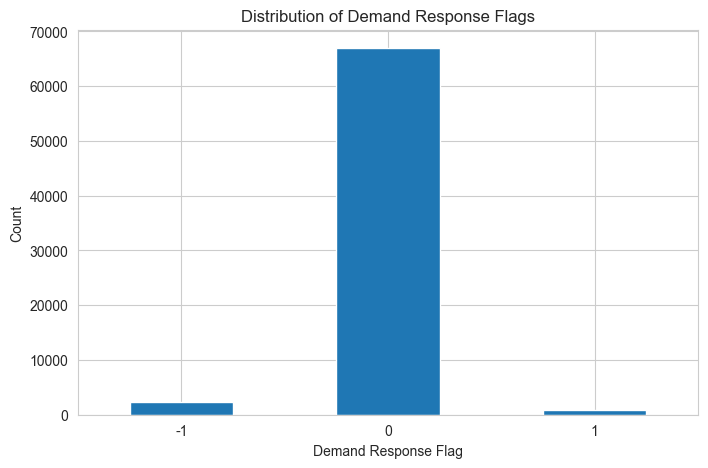

In [36]:
print("Demand Response Flag Distribution:")
print(df_filtered['Demand_Response_Flag'].value_counts().sort_index())
print("\nPercentages:")
print(df_filtered['Demand_Response_Flag'].value_counts(normalize=True).sort_index() * 100)

# Visualize
plt.figure(figsize=(8, 5))
df_filtered['Demand_Response_Flag'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Demand Response Flags')
plt.xlabel('Demand Response Flag')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()